In [1]:
import os
import sys
from pathlib import Path

# Automatically locate and add the 'src' folder to sys.path
project_root = Path(os.path.abspath(''))
src_path = project_root / "src"
if src_path not in sys.path:
    sys.path.insert(0, str(src_path))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, probplot
import patsy
import statsmodels.formula.api as smf
from scipy.stats import norm

from imaging import io

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SettingWithCopyWarning)
# warnings.filterwarnings('ignore')

In [2]:
db_base_path = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/')

db_clinical                   = pd.read_excel(db_base_path / 'PESABrain_Clinical_20260216.xlsx')
db_clinical_all               = pd.read_excel(db_base_path / 'PESABrain_Clinical_AllXNAT_20260216.xlsx')
db_subject_catalog_all        = pd.read_excel(db_base_path / 'PESABrain_SubjectCatalog_AllXNAT_20260216.xlsx')
db_all_ids                    = pd.read_excel(db_base_path / 'PESABrain_All_IDs.xlsx')
db_all_4dflow_ids             = pd.read_excel(db_base_path / 'PESABrain_All_4DFlow_IDs.xlsx')
      
db_hemo                       = pd.read_excel(db_base_path / 'PESABrain_LocHemodynamic_20260406.xlsx')
db_4dflow_loc_tavg_flow       = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedTimeAvgFlow_20260216.xlsx')
db_4dflow_loc_pi              = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedPI_20260216.xlsx')
db_4dflow_loc_tseries         = pd.read_excel(db_base_path / 'PESABrain_4DFlow_LocalizedTimeseriesFlow_Wide_20260216.xlsx')

db_asl_desikan_avg_perfusion  = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_ThrMeanCBF_20260216.xlsx')
db_asl_vascular_avg_perfusion = pd.read_excel(db_base_path / 'PESABrain_ASLPerfusion_VascularAtlas_MeanCBF_20260216.xlsx')

db_echo_carotide_plaque_vol   = pd.read_excel(db_base_path / 'PESABrain_Echography_CarotidePlaque_20260216.xlsx')
db_tac                        = pd.read_excel(db_base_path / 'PESABrain_TAC_20260318.xlsx')
db_apoe                       = pd.read_excel(db_base_path / 'PESABrain_APOE_20260318.xlsx')


subjects_all = db_all_ids.patient_id.unique()
subjects_4dflow_all = db_all_4dflow_ids.patient_id.unique()
subjects_4dflow_available = db_4dflow_loc_tavg_flow.patient_id.unique()

print(f'Total subjects: {len(subjects_all)}')
print(f'Total 4DFlow subjects: {len(subjects_4dflow_all)}')
print(f'Total 4DFlow available subjects: {len(subjects_4dflow_available)}')

Total subjects: 1001
Total 4DFlow subjects: 554
Total 4DFlow available subjects: 356


In [3]:
flow_cols = [col for col in db_hemo.columns if 'flow' in col]
for col in flow_cols:
    db_hemo[col] *= 60

db_hemo

,patient_id,lica_flow,lica_area,lica_psv,lica_pi,lica_ri,rica_flow,rica_area,rica_psv,rica_pi,...,laca_asl,lbasi_asl,lmca_asl,lpca_asl,raca_asl,rbasi_asl,rmca_asl,rpca_asl,ws_asl,age_c
0,PESA1006009,267.035802,0.185990,51.072498,0.701133,0.501405,281.351906,0.155110,73.136002,0.727263,...,57.143509,58.281823,54.680104,57.625703,59.824013,63.175530,56.890992,59.861298,50.179122,5.064663
1,PESA10061584,94.844843,0.052847,50.658012,0.639911,0.467598,207.560577,0.188077,41.568962,0.698219,...,41.327638,33.866011,42.331802,29.951558,38.817922,32.273991,38.077766,29.311260,27.110815,6.464663
2,PESA10067929,323.586469,0.177349,67.100998,0.773645,0.534933,355.117301,0.199957,65.818504,0.796976,...,57.639169,62.794067,59.787938,55.884712,62.024153,63.693485,61.698699,59.397221,55.872769,6.734663
3,PESA10086976,303.364359,0.196693,58.151039,0.540127,0.430462,0.814246,0.001630,13.636579,0.847596,...,55.158655,48.004188,57.096666,52.363161,58.912566,52.867965,60.446592,55.156248,51.348714,-4.615337
4,PESA10112400,325.856177,0.228517,56.140694,0.707761,0.513888,330.478438,0.266829,44.318054,0.791426,...,56.217818,34.247757,50.796234,42.679280,57.518873,34.655802,51.371223,42.014865,46.215967,-4.065337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,PESA9897316,283.497145,0.236773,41.451118,0.709040,0.513624,262.646432,0.213102,41.385551,0.782386,...,55.688677,45.282989,56.265623,44.485849,55.840209,45.742534,53.550264,44.541762,42.002036,-2.455337
352,PESA9928801,314.992869,0.263817,55.139935,0.850857,0.564423,370.991649,0.261477,57.409889,0.870882,...,55.200065,58.985057,54.112889,55.737723,57.223394,56.795652,58.131150,60.351909,49.882072,4.324663
353,PESA9935104,352.592480,0.225063,60.434376,0.753206,0.530925,199.660541,0.175714,44.200207,0.735158,...,52.431084,40.572026,54.236169,43.115527,50.796183,38.552160,54.130418,40.179098,46.629408,2.784663
354,PESA9947716,350.185589,0.246978,55.364765,0.807655,0.555005,358.434131,0.252401,54.714527,0.811330,...,61.730753,49.490786,66.492889,50.254449,66.573847,50.701696,72.198803,49.731519,55.293241,1.324663


In [4]:
VESSEL_TERRITORIES_MAP = {
    "Internal Carotid Arteries": ["lica", "rica"],
    "Venous Drainage": ["sssv", "strv", "ltsv", "rtsv"],
    "Anterior Circulation": [
        "lmca",
        "rmca",
        "laca",
        "raca",
    ],
    "Posterior Circulation": ["basi", "lpca", "rpca"],
}

base_territory_palette = {
    "MCA": "#1f77b4",
    "ACA": "#ff7f0e",
    "PCA": "#2ca02c",
    "ICA": "#d62728",
    "Basilar": "#9467bd",
    "Venous Drainage": "#8c564b",
    "Watershed": "#e377c2",
}

cmap = 'coolwarm'

cacs_order = ['None', 'Mild', 'Moderate', 'Severe']

pair_specs = [
    {
        "pair_label": "MCA",
        "pair_family": "Direct territorial",
        "macro_key": "MCA",
        "micro_key": "MCA",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "ACA",
        "pair_family": "Direct territorial",
        "macro_key": "ACA",
        "micro_key": "ACA",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "PCA",
        "pair_family": "Direct territorial",
        "macro_key": "PCA",
        "micro_key": "PCA",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "Basilar",
        "pair_family": "Direct territorial",
        "macro_key": "Basilar",
        "micro_key": "Basilar",
        "interpretation": "Direct arterial territory match",
    },
    {
        "pair_label": "ICA -> Anterior perfusion",
        "pair_family": "Upstream supply",
        "macro_key": "ICA",
        "micro_key": "Anterior perfusion",
        "interpretation": "ICA as proximal supply to the anterior circulation",
    },
    {
        "pair_label": "Proximal supply -> Watershed",
        "pair_family": "Borderzone supply",
        "macro_key": "Proximal supply",
        "micro_key": "Watershed",
        "interpretation": "Borderzone perfusion paired to aggregate proximal inflow",
    },
    {
        "pair_label": "Venous drainage -> Global perfusion",
        "pair_family": "Outflow coupling",
        "macro_key": "Venous Drainage",
        "micro_key": "Global perfusion",
        "interpretation": "Venous outflow paired to overall perfusion burden",
    },
]

combined_pair_order = [
    "MCA",
    "ACA",
    "PCA",
    "Basilar",
    "ICA -> Anterior perfusion",
    "Proximal supply -> Watershed",
    "Venous drainage -> Global perfusion",
]

### General

In [5]:
def _print_emm(df, mm_res, territory_order, additional_cols = None):
    def predict_fixed_ci_from_model(res, new_df):
        X = patsy.build_design_matrices(
            [res.model.data.design_info],
            new_df,
            return_type="dataframe",
        )[0]
        fe = res.fe_params
        cov = res.cov_params().loc[fe.index, fe.index]
        X = X.reindex(columns=fe.index, fill_value=0.0)

        pred = X @ fe
        se = np.sqrt(np.sum((X @ cov) * X, axis=1))

        out = new_df.copy()
        out["estimate"] = pred
        out["SE"] = se
        out["lower"] = pred - 1.96 * se
        out["upper"] = pred + 1.96 * se
        return out


    sex_ref = 0 # Female
    age_ref = 0
    hematocrit_ref = float(df["Hematocrit"].mean())

    emm_grid = pd.DataFrame(
        [(g, t) for g in cacs_order for t in territory_order],
        columns=["tacsctot_group", "territory_base"],
    )
    emm_grid["tacsctot_group"] = pd.Categorical(emm_grid["tacsctot_group"], categories=cacs_order, ordered=True)
    emm_grid["territory_base"] = pd.Categorical(emm_grid["territory_base"], categories=territory_order, ordered=True)
    emm_grid["age_c"] = age_ref
    emm_grid["sex"] = sex_ref
    emm_grid["Hematocrit"] = hematocrit_ref
    if additional_cols:
        for col in additional_cols:
            # emm_grid[col] = df[col].mean()
            emm_grid[col] = 0

    emm_df = predict_fixed_ci_from_model(mm_res, emm_grid)
    print("Estimated marginal means (adjusted model-based means):")
    print(emm_df[["tacsctot_group", "territory_base", "estimate", "SE", "lower", "upper"]])


    cacs_score_map = {g: i for i, g in enumerate(cacs_order)}
    emm_df["cacs_score"] = emm_df["tacsctot_group"].map(cacs_score_map).astype(float)

    slope_rows = []
    for terr in territory_order:
        sub = emm_df[emm_df["territory_base"] == terr].sort_values("cacs_score")
        slope = np.polyfit(sub["cacs_score"], sub["estimate"], 1)[0]
        severe_minus_none = float(
            sub.loc[sub["tacsctot_group"] == "Severe", "estimate"].iloc[0]
            - sub.loc[sub["tacsctot_group"] == "None", "estimate"].iloc[0]
        )
        slope_rows.append(
            {
                "territory_base": terr,
                "emm_slope_per_cacs_step": slope,
                "severe_minus_none": severe_minus_none,
            }
        )

    emm_slope_df = pd.DataFrame(slope_rows).sort_values("emm_slope_per_cacs_step")
    print("EMM-based slopes by territory:")
    print(emm_slope_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

    sns.pointplot(
        data=emm_df,
        x="cacs_score",
        y="estimate",
        hue="territory_base",
        palette=base_territory_palette,
        errorbar=None,
        markers="o",
        linestyles="-",
        ax=axes[0],
    )
    axes[0].set_xticks(range(len(cacs_order)))
    axes[0].set_xticklabels(cacs_order, rotation=20)
    axes[0].set_title("EMM trends across ordered CACS severity")
    axes[0].set_xlabel("CACS group")
    axes[0].set_ylabel("Adjusted mean flow")

    sns.barplot(
        data=emm_slope_df,
        x="emm_slope_per_cacs_step",
        y="territory_base",
        palette=base_territory_palette,
        ax=axes[1],
    )
    axes[1].axvline(0, ls="--", c="black", lw=1)
    axes[1].set_title("EMM-based slope per CACS step")
    axes[1].set_xlabel("Change in adjusted mean flow per CACS step")
    axes[1].set_ylabel("Territory")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles, labels, title="Territory", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.show()


def _fit_mm(
    df, feature = 'flow',
    mm_formula = None,
    groups_name = None,
    re_formula = None,
    vc_formula = None,
    print_emm = False,
    additional_cols = None,
):
    
    if feature in ['asl']:
        keep_cols = [
            'patient_id', 'age_c', 'sex', 'tacsctot_group', 'Hematocrit',
            f'laca_{feature}', f'raca_{feature}', f'lmca_{feature}', f'rmca_{feature}',
            f'lbasi_{feature}', f'rbasi_{feature}', f'lpca_{feature}', f'rpca_{feature}',
            f'ws_{feature}',
        ]
    else:
        keep_cols = [
            'patient_id', 'age_c', 'sex', 'tacsctot_group', 'Hematocrit',
            f'laca_{feature}', f'raca_{feature}', f'lmca_{feature}', f'rmca_{feature}',
            f'lica_{feature}', f'rica_{feature}',
            f'sssv_{feature}', f'strv_{feature}', f'ltsv_{feature}', f'rtsv_{feature}',
            f'basi_{feature}', f'lpca_{feature}', f'rpca_{feature}',
        ]
    if additional_cols:
        keep_cols.extend(additional_cols)
    df = df[keep_cols]

    cacs_map = {'g0': 'None', 'g1': "Mild", 'g2': "Moderate", 'g3': "Severe"}
    cacs_order = ['None', 'Mild', 'Moderate', 'Severe']
    df["tacsctot_group"] = df["tacsctot_group"].map(cacs_map)
    df["tacsctot_group"] = pd.Categorical(df["tacsctot_group"], categories=cacs_order, ordered=True)

    # ---------------------------------------------------
    # 2. Build bilateral territory-level mean flow values
    # ---------------------------------------------------
    if feature in ['asl']:
        territory_order = ["MCA", "ACA", "PCA", "Basilar", "Watershed"]
        df["Basilar"] = df[[f"rbasi_{feature}", f"lbasi_{feature}"]].mean(axis=1)
        df['Watershed'] = df[[f"ws_{feature}"]].mean(axis=1)
    else:
        territory_order = ["MCA", "ACA", "ICA", "PCA", "Basilar", "Venous Drainage"]
        df["Basilar"] = df[[f"basi_{feature}"]].mean(axis=1)
        df["ICA"] = df[[f"lica_{feature}", f"rica_{feature}"]].mean(axis=1)
        df["Venous Drainage"] = df[[f"sssv_{feature}", f"strv_{feature}", f"ltsv_{feature}", f"rtsv_{feature}"]].mean(axis=1)
    df["PCA"] = df[[f"lpca_{feature}", f"rpca_{feature}"]].mean(axis=1)
    df["ACA"] = df[[f"laca_{feature}", f"raca_{feature}"]].mean(axis=1)
    df["MCA"] = df[[f"lmca_{feature}", f"rmca_{feature}"]].mean(axis=1)

    _add = [] if not additional_cols else additional_cols
    db_long = df.melt(
        id_vars=["patient_id", "age_c", "sex", "tacsctot_group", "Hematocrit"] + _add,
        value_vars=territory_order,
        var_name="territory_base",
        value_name=feature
    ).dropna()

    
    db_long["territory_base"] = pd.Categorical(
        db_long["territory_base"],
        categories=territory_order,
        ordered=True
    )

    # ---------------------------------------------------
    # 3. Mixed model
    # ---------------------------------------------------
    if not mm_formula:
        mm_formula = (
            f"{feature} ~ C(tacsctot_group, Treatment('None')) "
            "* C(territory_base, Treatment('MCA')) + age_c + sex + Hematocrit"
        )
        groups = db_long["territory_base"]
        re_formula = "0"
        vc_formula = {"patient": "0 + C(patient_id)"}
    else: groups = db_long[groups_name]

    mixed_model = smf.mixedlm(
        mm_formula,
        data=db_long,
        groups=groups,
        re_formula=re_formula,
        vc_formula=vc_formula,
    )
    mm_res = mixed_model.fit()
    if print_emm:
        _print_emm(df, mm_res, territory_order, additional_cols)
    return mm_res

### flow ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + age_c + sex + Hematocrit + (1|territory_base) + (1|patient_id)

Estimated marginal means (adjusted model-based means):
   tacsctot_group   territory_base    estimate         SE       lower  \
0            None              MCA   89.687728  15.267361   59.763700   
1            None              ACA   21.424175  15.267361   -8.499853   
2            None              ICA  212.686443  15.263077  182.770813   
3            None              PCA   -8.221654  15.267361  -38.145682   
4            None          Basilar   97.145860  15.263077   67.230230   
5            None  Venous Drainage  151.184634  15.267361  121.260606   
6            Mild              MCA   88.444876  15.357576   58.344026   
7            Mild              ACA   23.224300  15.357576   -6.876550   
8            Mild              ICA  214.443972  15.363726  184.331069   
9            Mild              PCA   -4.129316  15.357576  -34.230166   
10           Mild          Basilar   92.556313  15.363726   62.443410   
11           Mild  Venous Drainage  137.197891  15.357576  107.097042

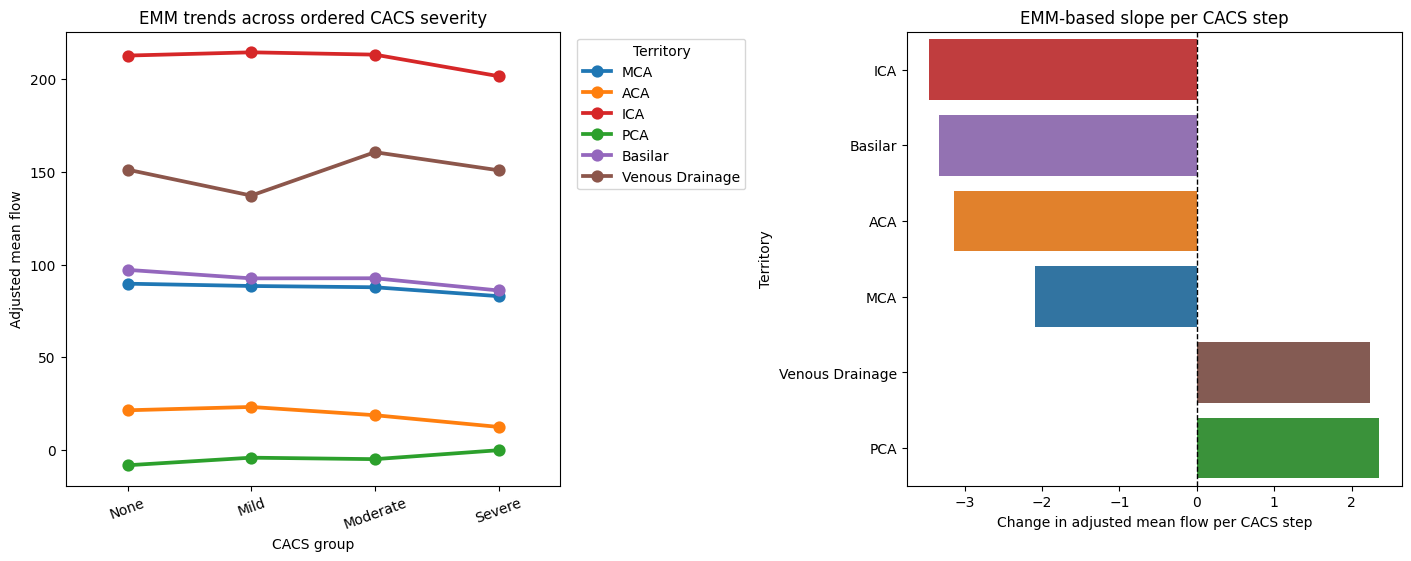

In [ ]:
df = db_hemo.copy()

mm_res = _fit_mm(
    df, feature = 'flow',
    mm_formula = f"flow ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + age_c + sex + Hematocrit",
    groups_name = "territory_base",
    re_formula = "0",
    vc_formula = {"patient": "0 + C(patient_id)"},
    print_emm = True
)

Perfusion

Estimated marginal means (adjusted model-based means):
   tacsctot_group territory_base   estimate        SE      lower      upper
0            None            MCA  55.792910  0.644200  54.530278  57.055541
1            None            ACA  55.518771  0.644200  54.256139  56.781402
2            None            PCA  50.752402  0.644200  49.489770  52.015033
3            None        Basilar  51.442157  0.644200  50.179526  52.704789
4            None      Watershed  46.826089  0.644200  45.563458  48.088721
5            Mild            MCA  57.421405  0.905685  55.646262  59.196548
6            Mild            ACA  57.121995  0.905685  55.346852  58.897138
7            Mild            PCA  50.049431  0.905685  48.274288  51.824575
8            Mild        Basilar  50.534141  0.905685  48.758998  52.309284
9            Mild      Watershed  47.033775  0.905685  45.258632  48.808918
10       Moderate            MCA  56.886600  1.526993  53.893694  59.879506
11       Moderate            ACA 

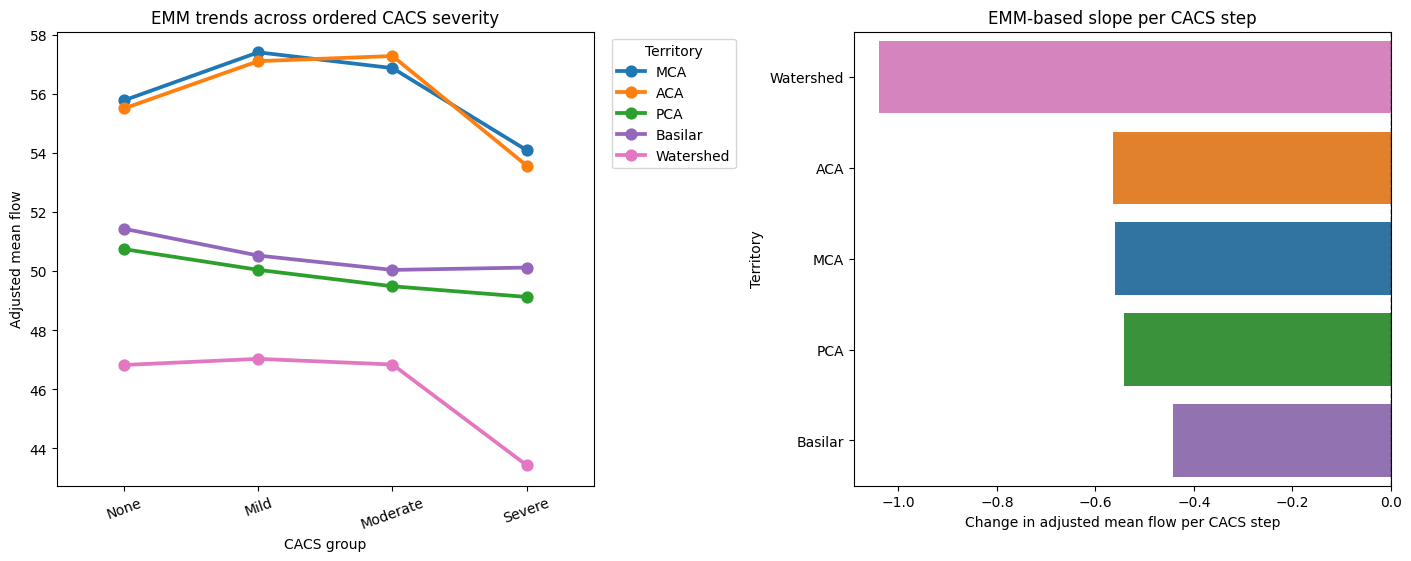

In [12]:
df = db_hemo.copy()

mm_res = _fit_mm(
    df, feature = 'asl',
    mm_formula = f"asl ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + age_c + sex + Hematocrit",
    groups_name = "territory_base",
    re_formula = "0",
    vc_formula = {"patient": "0 + C(patient_id)"},
    print_emm = True
)


Estimated marginal means (adjusted model-based means):
   tacsctot_group territory_base   estimate        SE      lower      upper
0            None            MCA  55.754846  0.881137  54.027817  57.481874
1            None            ACA  55.480707  0.881026  53.753895  57.207518
2            None            PCA  50.714338  0.885229  48.979289  52.449386
3            None        Basilar  51.404093  0.921538  49.597879  53.210307
4            None      Watershed  46.788025  0.874563  45.073882  48.502169
5            Mild            MCA  57.462198  1.244761  55.022467  59.901930
6            Mild            ACA  57.162788  1.244604  54.723364  59.602212
7            Mild            PCA  50.090225  1.250554  47.639139  52.541311
8            Mild        Basilar  50.574934  1.301956  48.023101  53.126767
9            Mild      Watershed  47.074569  1.235454  44.653079  49.496059
10       Moderate            MCA  56.940868  1.851571  53.311789  60.569947
11       Moderate            ACA 

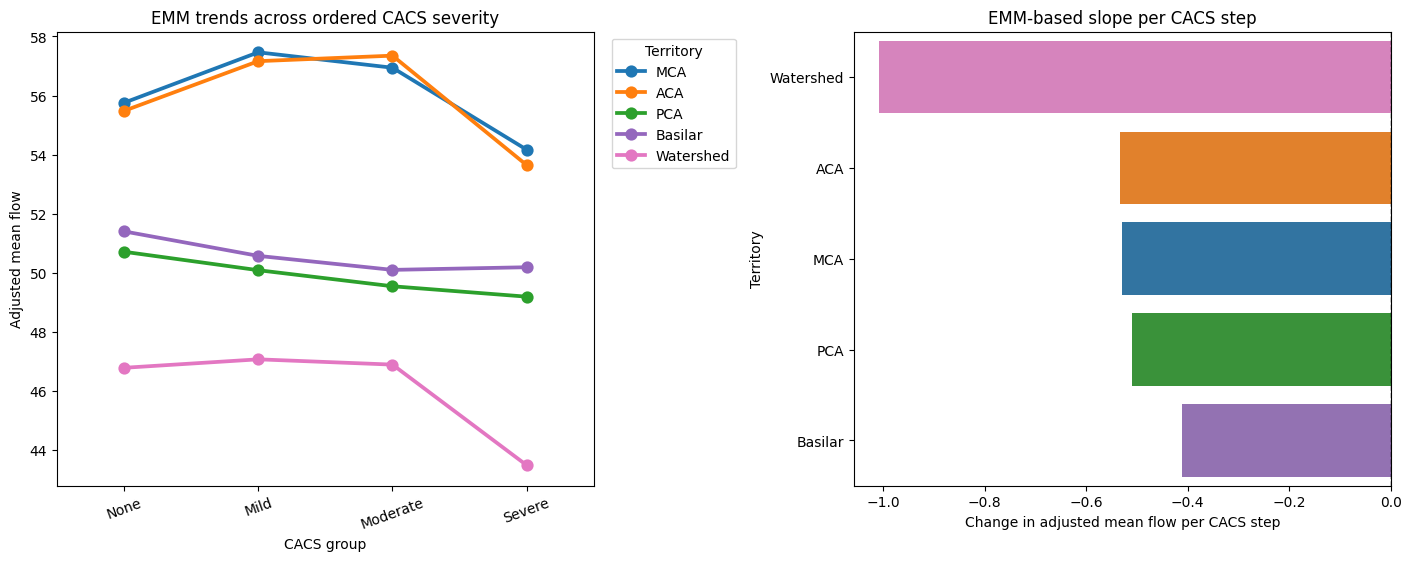

In [13]:

mm_res = _fit_mm(
    df, feature = 'asl',
    mm_formula = f"asl ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + age_c + sex + Hematocrit",
    groups_name = "patient_id",
    re_formula = "0 + C(territory_base)",
    vc_formula = {"patient": "0 + C(patient_id)"},
    print_emm = True
)

Estimated marginal means (adjusted model-based means):
   tacsctot_group territory_base   estimate        SE      lower      upper
0            None            MCA  56.618910  0.779888  55.090330  58.147490
1            None            ACA  56.342594  0.779888  54.814014  57.871174
2            None            PCA  51.551546  0.779888  50.022966  53.080126
3            None        Basilar  52.260828  0.779888  50.732248  53.789408
4            None      Watershed  47.628533  0.779888  46.099953  49.157113
5            Mild            MCA  58.338447  1.004782  56.369074  60.307820
6            Mild            ACA  58.049392  1.004782  56.080018  60.018765
7            Mild            PCA  50.984200  1.004782  49.014826  52.953573
8            Mild        Basilar  51.457271  1.004782  49.487898  53.426644
9            Mild      Watershed  47.925369  1.004782  45.955996  49.894742
10       Moderate            MCA  57.855053  1.606065  54.707164  61.002941
11       Moderate            ACA 

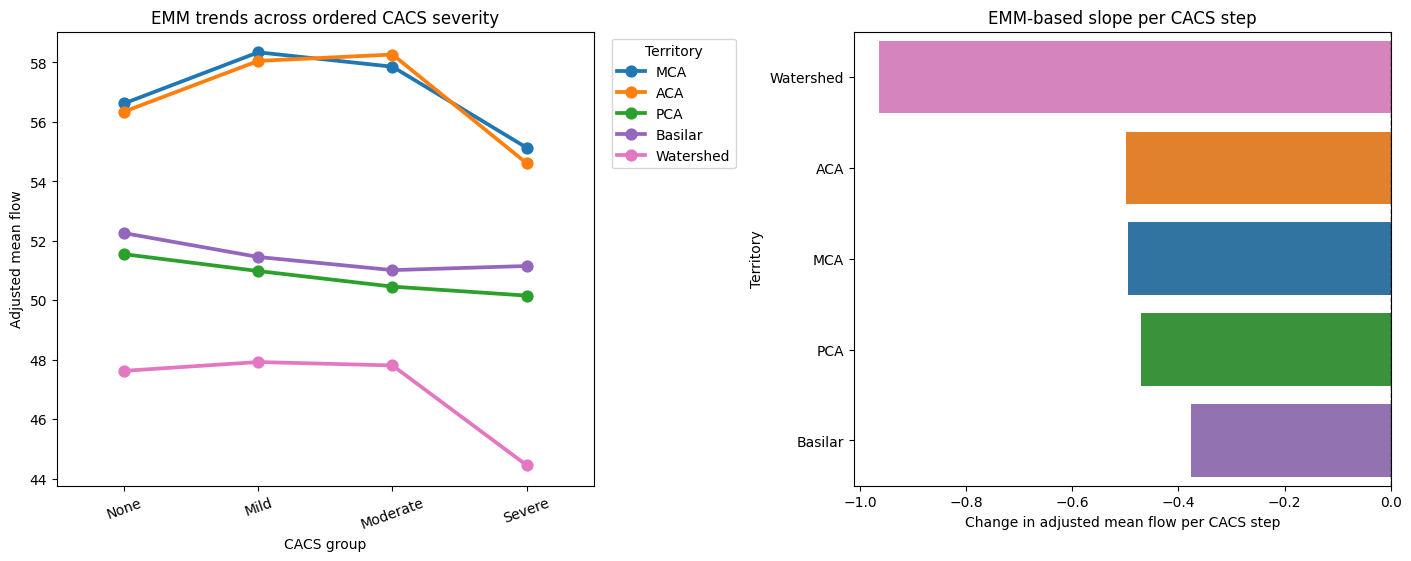

In [26]:
df = db_hemo.copy()

mm_res = _fit_mm(
    df, feature = 'asl',
    mm_formula = f"asl ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    groups_name = "patient_id",
    re_formula = "0",
    vc_formula = {"territory_base": "0 + C(territory_base)"},
    print_emm = True,
    additional_cols = ["SCORE2"]
)

PI

Estimated marginal means (adjusted model-based means):
   tacsctot_group   territory_base  estimate        SE     lower     upper
0            None              MCA  0.769080  0.012457  0.744665  0.793495
1            None              ACA  0.818671  0.012457  0.794256  0.843086
2            None              ICA  0.762172  0.012544  0.737586  0.786759
3            None              PCA  0.867462  0.012457  0.843047  0.891877
4            None          Basilar  0.756581  0.012544  0.731994  0.781167
5            None  Venous Drainage  0.450688  0.012457  0.426272  0.475103
6            Mild              MCA  0.802051  0.016216  0.770268  0.833833
7            Mild              ACA  0.815600  0.016216  0.783817  0.847382
8            Mild              ICA  0.781793  0.016367  0.749714  0.813872
9            Mild              PCA  0.851816  0.016216  0.820034  0.883599
10           Mild          Basilar  0.744359  0.016367  0.712280  0.776438
11           Mild  Venous Drainage  0.454422 

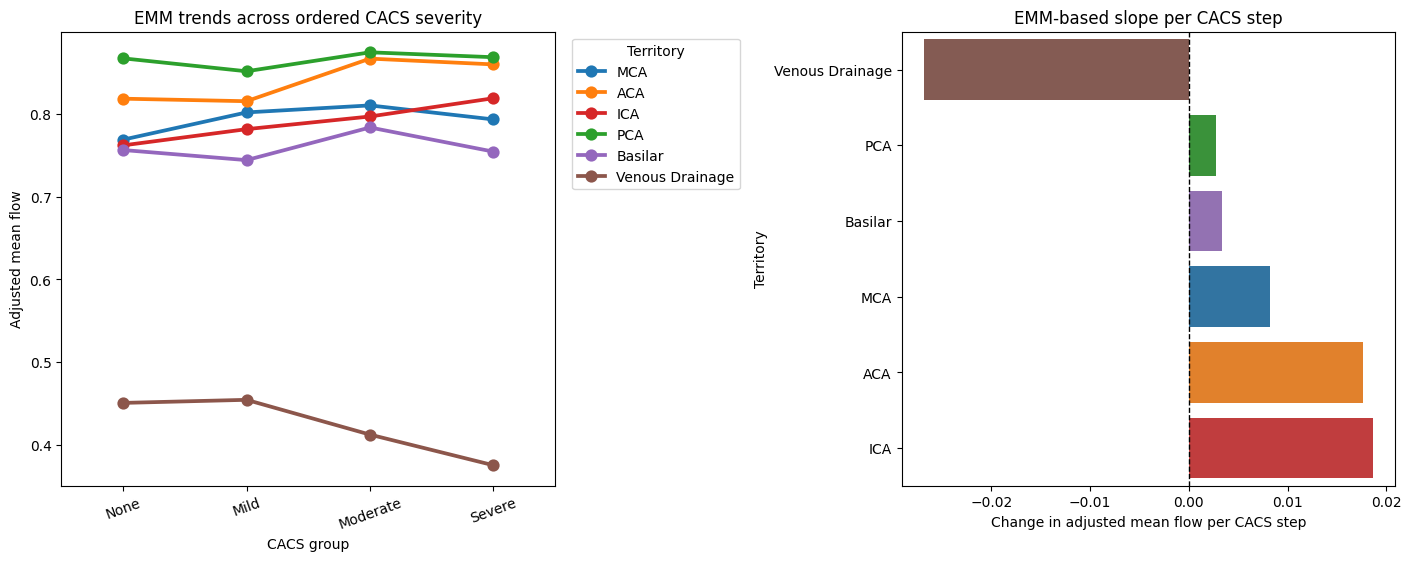

In [29]:
df = db_hemo.copy()

mm_res = _fit_mm(
    df, feature = 'pi',
    mm_formula = f"pi ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    groups_name = "patient_id",
    re_formula = "0",
    vc_formula = {"territory_base": "0 + C(territory_base)"},
    print_emm = True,
    additional_cols = ["SCORE2"]
)

Area

Estimated marginal means (adjusted model-based means):
   tacsctot_group   territory_base  estimate        SE     lower     upper
0            None              MCA  0.096899  0.005436  0.086244  0.107554
1            None              ACA  0.065528  0.005436  0.054873  0.076183
2            None              ICA  0.226973  0.005474  0.216244  0.237703
3            None              PCA  0.056913  0.005436  0.046258  0.067568
4            None          Basilar  0.097782  0.005474  0.087053  0.108512
5            None  Venous Drainage  0.255377  0.005436  0.244722  0.266032
6            Mild              MCA  0.095873  0.007077  0.082003  0.109744
7            Mild              ACA  0.064071  0.007077  0.050200  0.077941
8            Mild              ICA  0.242347  0.007143  0.228347  0.256347
9            Mild              PCA  0.054928  0.007077  0.041058  0.068799
10           Mild          Basilar  0.102481  0.007143  0.088481  0.116481
11           Mild  Venous Drainage  0.239158 

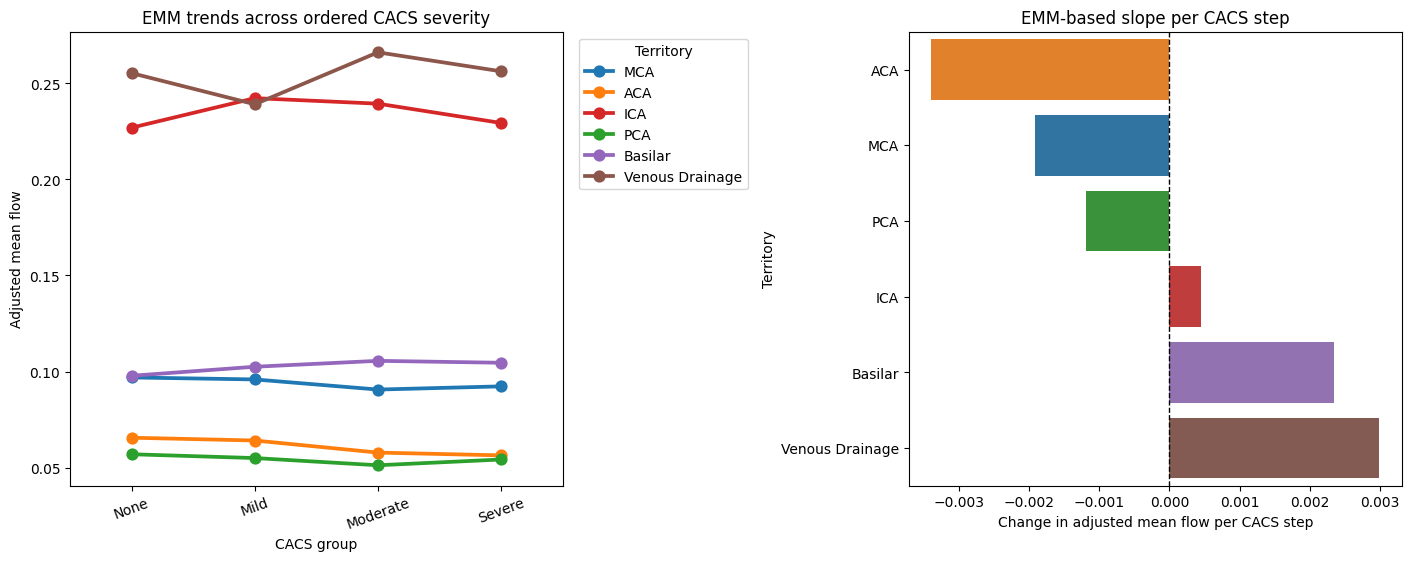

In [28]:
df = db_hemo.copy()

mm_res = _fit_mm(
    df, feature = 'area',
    mm_formula = f"area ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    groups_name = "patient_id",
    re_formula = "0",
    vc_formula = {"territory_base": "0 + C(territory_base)"},
    print_emm = True,
    additional_cols = ["SCORE2"]
)

PSV

Estimated marginal means (adjusted model-based means):
   tacsctot_group   territory_base   estimate        SE      lower      upper
0            None              MCA  64.024589  0.845228  62.367943  65.681236
1            None              ACA  53.934903  0.845228  52.278257  55.591550
2            None              ICA  54.312393  0.851166  52.644107  55.980679
3            None              PCA  42.331974  0.845228  40.675327  43.988620
4            None          Basilar  57.978493  0.851166  56.310206  59.646779
5            None  Venous Drainage  33.703184  0.845228  32.046538  35.359831
6            Mild              MCA  62.712558  1.100281  60.556008  64.869108
7            Mild              ACA  53.705965  1.100281  51.549415  55.862515
8            Mild              ICA  51.097645  1.110546  48.920974  53.274315
9            Mild              PCA  42.417573  1.100281  40.261023  44.574123
10           Mild          Basilar  54.624410  1.110546  52.447739  56.801080
11       

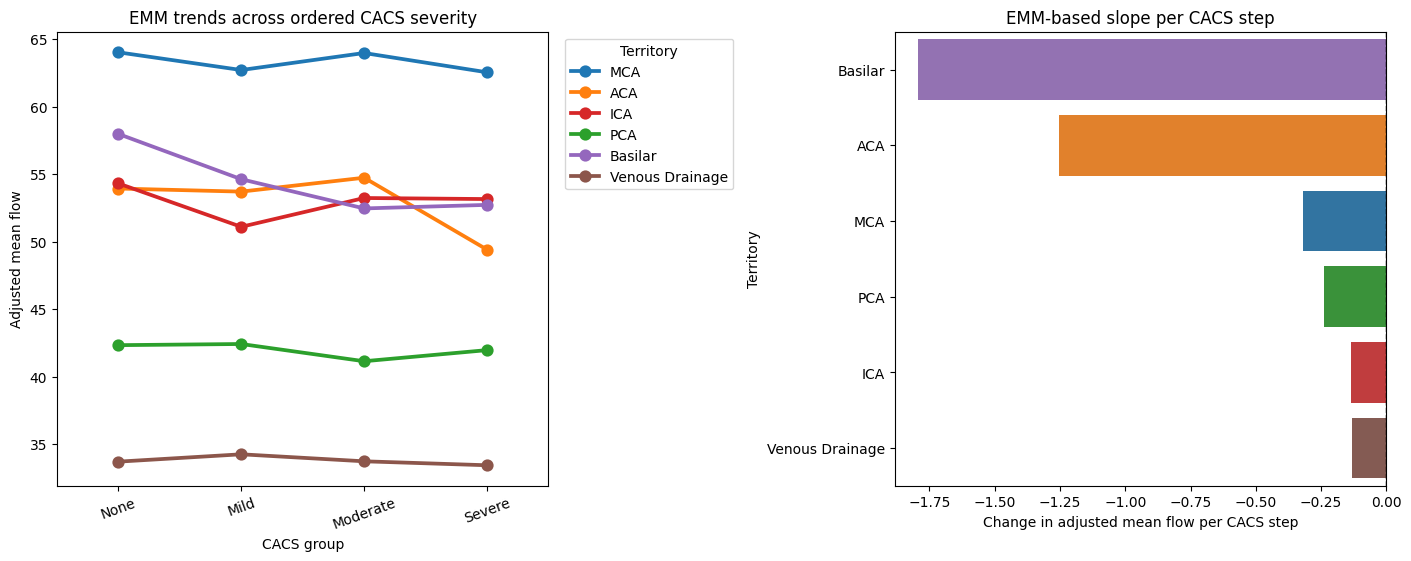

In [30]:
df = db_hemo.copy()

mm_res = _fit_mm(
    df, feature = 'psv',
    mm_formula = f"psv ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    groups_name = "patient_id",
    re_formula = "0",
    vc_formula = {"territory_base": "0 + C(territory_base)"},
    print_emm = True,
    additional_cols = ["SCORE2"]
)

Flow - Perfusion missmatch

In [15]:
pair_df = db_hemo.copy()

cacs_map = {'g0': 'None', 'g1': 'Mild', 'g2': 'Moderate', 'g3': 'Severe'}
cacs_order = ['None', 'Mild', 'Moderate', 'Severe']
territory_order = ['MCA', 'ACA', 'PCA', 'Basilar']

pair_df['tacsctot_group'] = pair_df['tacsctot_group'].map(cacs_map)
pair_df['tacsctot_group'] = pd.Categorical(pair_df['tacsctot_group'], categories=cacs_order, ordered=True)

flow_df = pd.DataFrame({
    'patient_id': pair_df['patient_id'],
    'MCA': pair_df[['lmca_flow', 'rmca_flow']].mean(axis=1),
    'ACA': pair_df[['laca_flow', 'raca_flow']].mean(axis=1),
    'PCA': pair_df[['lpca_flow', 'rpca_flow']].mean(axis=1),
    'Basilar': pair_df[['basi_flow']].mean(axis=1),
})

asl_df = pd.DataFrame({
    'patient_id': pair_df['patient_id'],
    'MCA': pair_df[['lmca_asl', 'rmca_asl']].mean(axis=1),
    'ACA': pair_df[['laca_asl', 'raca_asl']].mean(axis=1),
    'PCA': pair_df[['lpca_asl', 'rpca_asl']].mean(axis=1),
    'Basilar': pair_df[['lbasi_asl', 'rbasi_asl']].mean(axis=1),
})

flow_long = flow_df.melt(id_vars='patient_id', var_name='territory_base', value_name='macro_flow')
asl_long = asl_df.melt(id_vars='patient_id', var_name='territory_base', value_name='micro_cbf')

clin_cols = ['patient_id', 'age_c', 'sex', 'Hematocrit', 'tacsctot_group', 'SCORE2']
clin_df = pair_df[clin_cols].drop_duplicates('patient_id')

pair_long = (
    flow_long
    .merge(asl_long, on=['patient_id', 'territory_base'], how='inner')
    .merge(clin_df, on='patient_id', how='left')
    .dropna(subset=['macro_flow', 'micro_cbf', 'age_c', 'sex', 'Hematocrit', 'tacsctot_group'])
    .reset_index(drop=True)
)

pair_long['territory_base'] = pd.Categorical(
    pair_long['territory_base'],
    categories=territory_order,
    ordered=True
)

In [16]:
pair_long

,patient_id,territory_base,macro_flow,micro_cbf,age_c,sex,Hematocrit,tacsctot_group,SCORE2
0,PESA1006009,MCA,174.516401,55.785548,5.064663,1,47.0,None,4.625464
1,PESA10061584,MCA,111.893086,40.204784,6.464663,1,48.0,Moderate,5.979170
2,PESA10067929,MCA,254.672377,60.743318,6.734663,1,42.0,None,7.063850
3,PESA10086976,MCA,236.563713,58.771629,-4.615337,0,45.0,None,1.596673
4,PESA10112400,MCA,199.062201,51.083729,-4.065337,1,48.0,None,3.986971
...,...,...,...,...,...,...,...,...,...
1387,PESA9897316,Basilar,178.221377,45.512762,-2.455337,1,52.0,Mild,4.760891
1388,PESA9928801,Basilar,87.832792,57.890354,4.324663,0,45.0,None,2.783649
1389,PESA9935104,Basilar,245.827435,39.562093,2.784663,0,45.0,None,2.478144
1390,PESA9947716,Basilar,309.712580,50.096241,1.324663,1,42.0,Mild,3.722326


In [17]:
def safe_z(x):
    s = x.std(ddof=0)
    if pd.isna(s) or s == 0:
        return pd.Series(np.nan, index=x.index)
    return (x - x.mean()) / s

pair_long['macro_flow_z'] = pair_long.groupby('territory_base')['macro_flow'].transform(safe_z)
pair_long['micro_cbf_z'] = pair_long.groupby('territory_base')['micro_cbf'].transform(safe_z)

pair_long['flow_cbf_mismatch_z'] = pair_long['macro_flow_z'] - pair_long['micro_cbf_z']

Estimated marginal means for residualized mismatch:
   tacsctot_group territory_base  estimate        SE     lower     upper
0            None            MCA -0.035609  0.034804 -0.103824  0.032607
1            None            ACA -0.042523  0.034804 -0.110739  0.025693
2            None            PCA  0.036024  0.034804 -0.032192  0.104239
3            None        Basilar  0.038677  0.035019 -0.029960  0.107313
4            Mild            MCA  0.075807  0.044226 -0.010877  0.162490
5            Mild            ACA  0.071087  0.044226 -0.015596  0.157771
6            Mild            PCA -0.061572  0.044226 -0.148255  0.025112
7            Mild        Basilar -0.080649  0.044623 -0.168110  0.006813
8        Moderate            MCA  0.044867  0.069405 -0.091167  0.180901
9        Moderate            ACA  0.118246  0.069405 -0.017788  0.254280
10       Moderate            PCA -0.085797  0.069405 -0.221830  0.050237
11       Moderate        Basilar -0.081327  0.070371 -0.219254  0.056600

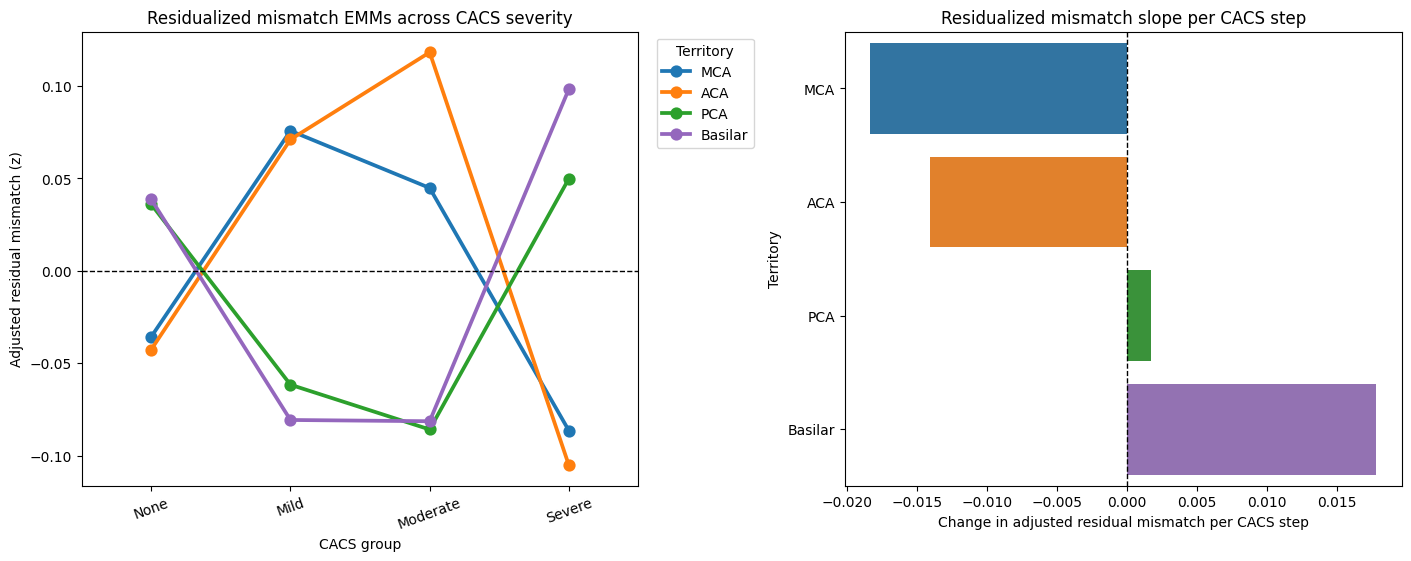

(   tacsctot_group territory_base  age_c  sex  Hematocrit  SCORE2  estimate  \
 0            None            MCA      0    0   45.024566       0 -0.035609   
 1            None            ACA      0    0   45.024566       0 -0.042523   
 2            None            PCA      0    0   45.024566       0  0.036024   
 3            None        Basilar      0    0   45.024566       0  0.038677   
 4            Mild            MCA      0    0   45.024566       0  0.075807   
 5            Mild            ACA      0    0   45.024566       0  0.071087   
 6            Mild            PCA      0    0   45.024566       0 -0.061572   
 7            Mild        Basilar      0    0   45.024566       0 -0.080649   
 8        Moderate            MCA      0    0   45.024566       0  0.044867   
 9        Moderate            ACA      0    0   45.024566       0  0.118246   
 10       Moderate            PCA      0    0   45.024566       0 -0.085797   
 11       Moderate        Basilar      0    0   45.0

In [ ]:
model_df = pair_long[
  [
      "patient_id",
      "micro_cbf_z",
      "macro_flow_z",
      "territory_base",
      "tacsctot_group",
      "SCORE2",
      "age_c",
      "sex",
      "Hematocrit",
  ]
].dropna().reset_index(drop=True)

res_expected = smf.mixedlm(
    "micro_cbf_z ~ macro_flow_z + C(territory_base, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()

model_df['cbf_expected_z'] = res_expected.fittedvalues
model_df['cbf_resid_mismatch_z'] = model_df['micro_cbf_z'] - model_df['cbf_expected_z']

res_resid_mismatch = smf.mixedlm(
    "cbf_resid_mismatch_z ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()


def _print_resid_mismatch_emm(df, mm_res, territory_order, additional_cols=None):
    def predict_fixed_ci_from_model(res, new_df):
        X = patsy.build_design_matrices(
            [res.model.data.design_info],
            new_df,
            return_type="dataframe",
        )[0]
        fe = res.fe_params
        cov = res.cov_params().loc[fe.index, fe.index]
        X = X.reindex(columns=fe.index, fill_value=0.0)

        pred = X @ fe
        se = np.sqrt(np.sum((X @ cov) * X, axis=1))

        out = new_df.copy()
        out["estimate"] = pred
        out["SE"] = se
        out["lower"] = pred - 1.96 * se
        out["upper"] = pred + 1.96 * se
        return out

    sex_ref = 0          # female
    age_ref = 0          # because age_c is centered
    hematocrit_ref = float(df["Hematocrit"].mean())

    emm_grid = pd.DataFrame(
        [(g, t) for g in cacs_order for t in territory_order],
        columns=["tacsctot_group", "territory_base"],
    )
    emm_grid["tacsctot_group"] = pd.Categorical(
        emm_grid["tacsctot_group"], categories=cacs_order, ordered=True
    )
    emm_grid["territory_base"] = pd.Categorical(
        emm_grid["territory_base"], categories=territory_order, ordered=True
    )
    emm_grid["age_c"] = age_ref
    emm_grid["sex"] = sex_ref
    emm_grid["Hematocrit"] = hematocrit_ref

    if additional_cols:
        for col in additional_cols:
            # use 0 only if the variable is centered; otherwise use the mean
            emm_grid[col] = 0

    emm_df = predict_fixed_ci_from_model(mm_res, emm_grid)

    print("Estimated marginal means for residualized mismatch:")
    print(
        emm_df[
            ["tacsctot_group", "territory_base", "estimate", "SE", "lower", "upper"]
        ]
    )

    print(
        "\nInterpretation: negative = lower ASL CBF than expected for the available flow; "
        "positive = higher ASL CBF than expected for the available flow."
    )

    cacs_score_map = {g: i for i, g in enumerate(cacs_order)}
    emm_df["cacs_score"] = emm_df["tacsctot_group"].map(cacs_score_map).astype(float)

    slope_rows = []
    for terr in territory_order:
        sub = emm_df[emm_df["territory_base"] == terr].sort_values("cacs_score")
        slope = np.polyfit(sub["cacs_score"], sub["estimate"], 1)[0]
        severe_minus_none = float(
            sub.loc[sub["tacsctot_group"] == "Severe", "estimate"].iloc[0]
            - sub.loc[sub["tacsctot_group"] == "None", "estimate"].iloc[0]
        )
        slope_rows.append(
            {
                "territory_base": terr,
                "emm_slope_per_cacs_step": slope,
                "severe_minus_none": severe_minus_none,
            }
        )

    emm_slope_df = pd.DataFrame(slope_rows).sort_values("emm_slope_per_cacs_step")
    print("\nEMM-based slopes for residualized mismatch by territory:")
    print(emm_slope_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

    sns.pointplot(
        data=emm_df,
        x="cacs_score",
        y="estimate",
        hue="territory_base",
        palette=base_territory_palette,
        errorbar=None,
        markers="o",
        linestyles="-",
        ax=axes[0],
    )
    axes[0].axhline(0, ls="--", c="black", lw=1)
    axes[0].set_xticks(range(len(cacs_order)))
    axes[0].set_xticklabels(cacs_order, rotation=20)
    axes[0].set_title("Residualized mismatch EMMs across CACS severity")
    axes[0].set_xlabel("CACS group")
    axes[0].set_ylabel("Adjusted residual mismatch (z)")

    sns.barplot(
        data=emm_slope_df,
        x="emm_slope_per_cacs_step",
        y="territory_base",
        palette=base_territory_palette,
        ax=axes[1],
    )
    axes[1].axvline(0, ls="--", c="black", lw=1)
    axes[1].set_title("Residualized mismatch slope per CACS step")
    axes[1].set_xlabel("Change in adjusted residual mismatch per CACS step")
    axes[1].set_ylabel("Territory")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles, labels, title="Territory", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.show()

    return emm_df, emm_slope_df

_print_resid_mismatch_emm(model_df, res_resid_mismatch, territory_order, additional_cols=["SCORE2"])

In [51]:
model_df = pair_long[
  [
      "patient_id",
      "micro_cbf_z",
      "macro_flow_z",
      "territory_base",
      "tacsctot_group",
      "SCORE2",
      "age_c",
      "sex",
      "Hematocrit",
      "flow_cbf_mismatch_z"
  ]
].dropna().reset_index(drop=True)

res_mismatch = smf.mixedlm(
    "flow_cbf_mismatch_z ~ C(tacsctot_group, Treatment('None')) * C(territory_base, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()
print(res_mismatch.summary())

                                                  Mixed Linear Model Regression Results
Model:                                     MixedLM                         Dependent Variable:                         flow_cbf_mismatch_z
No. Observations:                          1384                            Method:                                     REML               
No. Groups:                                348                             Scale:                                      0.8269             
Min. group size:                           3                               Log-Likelihood:                             -2046.7796         
Max. group size:                           4                               Converged:                                  Yes                
Mean group size:                           4.0                                                                                            
------------------------------------------------------------------------------

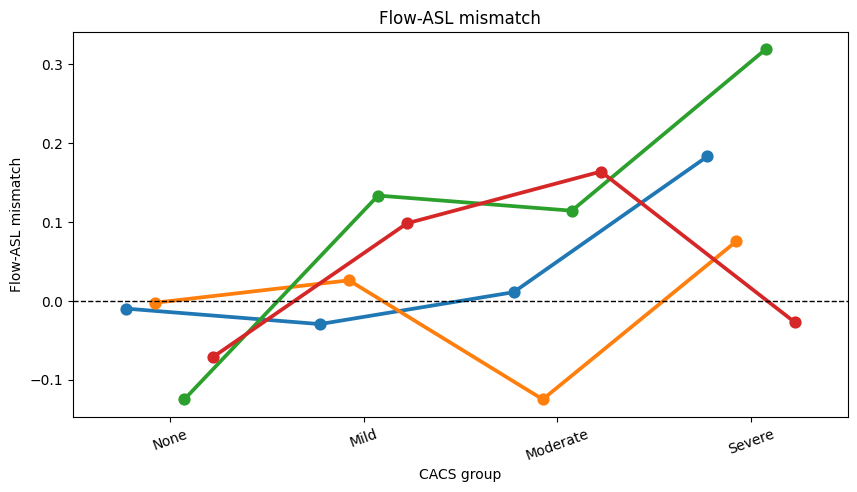

In [50]:

def lineplot_from_long(ax, df, value_col, title, ylabel, add_zero=True):
    plot_df = df.copy()
    plot_df["territory_base"] = pd.Categorical(
        plot_df["territory_base"],
        categories=territory_order,
        ordered=True,
    )
    plot_df["tacsctot_group"] = pd.Categorical(
        plot_df["tacsctot_group"],
        categories=cacs_order,
        ordered=True,
    )

    sns.pointplot(
        data=plot_df,
        x="tacsctot_group",
        y=value_col,
        hue="territory_base",
        order=cacs_order,
        hue_order=territory_order,
        # palette=pair_palette,
        dodge=0.45,
        errorbar=None,
        markers="o",
        linestyles="-",
        estimator=np.mean,
        ax=ax,
    )
    if add_zero:
        ax.axhline(0, ls="--", c="black", lw=1)
    ax.set_title(title)
    ax.set_xlabel("CACS group")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
lineplot_from_long(ax, pair_long, "flow_cbf_mismatch_z", "Flow-ASL mismatch", "Flow-ASL mismatch")


In [19]:
pair_df = db_hemo.copy()

cacs_map = {'g0': 'None', 'g1': 'Mild', 'g2': 'Moderate', 'g3': 'Severe'}
cacs_order = ['None', 'Mild', 'Moderate', 'Severe']
pair_order = combined_pair_order

pair_df['tacsctot_group'] = pair_df['tacsctot_group'].map(cacs_map)
pair_df['tacsctot_group'] = pd.Categorical(
    pair_df['tacsctot_group'],
    categories=cacs_order,
    ordered=True,
)

# -------------------------
# Macro flow sources
# -------------------------
flow_metrics = pd.DataFrame({
    'patient_id': pair_df['patient_id'],
    'MCA': pair_df[['lmca_flow', 'rmca_flow']].mean(axis=1),
    'ACA': pair_df[['laca_flow', 'raca_flow']].mean(axis=1),
    'PCA': pair_df[['lpca_flow', 'rpca_flow']].mean(axis=1),
    'Basilar': pair_df[['basi_flow']].mean(axis=1),
    'ICA': pair_df[['lica_flow', 'rica_flow']].mean(axis=1),
    'Venous Drainage': pair_df[['sssv_flow', 'strv_flow', 'ltsv_flow', 'rtsv_flow']].mean(axis=1),
})

flow_metrics['Proximal supply'] = flow_metrics[['ICA', 'Basilar']].mean(axis=1)

# -------------------------
# Micro perfusion targets
# -------------------------
asl_metrics = pd.DataFrame({
    'patient_id': pair_df['patient_id'],
    'MCA': pair_df[['lmca_asl', 'rmca_asl']].mean(axis=1),
    'ACA': pair_df[['laca_asl', 'raca_asl']].mean(axis=1),
    'PCA': pair_df[['lpca_asl', 'rpca_asl']].mean(axis=1),
    'Basilar': pair_df[['lbasi_asl', 'rbasi_asl']].mean(axis=1),
    'Watershed': pair_df[['ws_asl']].mean(axis=1),
})

asl_metrics['Anterior perfusion'] = asl_metrics[['MCA', 'ACA']].mean(axis=1)
asl_metrics['Global perfusion'] = asl_metrics[['MCA', 'ACA', 'PCA', 'Basilar', 'Watershed']].mean(axis=1)

# -------------------------
# Clinical covariates
# -------------------------
clin_cols = ['patient_id', 'age_c', 'sex', 'Hematocrit', 'tacsctot_group', 'SCORE2']
clin_df = pair_df[clin_cols].drop_duplicates('patient_id')

# -------------------------
# Pair-based long table
# -------------------------
pair_parts = []
for spec in pair_specs:
    part = pd.DataFrame({
        'patient_id': pair_df['patient_id'],
        'pair_label': spec['pair_label'],
        'pair_family': spec['pair_family'],
        'macro_source': spec['macro_key'],
        'micro_target': spec['micro_key'],
        'macro_flow': flow_metrics[spec['macro_key']],
        'micro_cbf': asl_metrics[spec['micro_key']],
    })
    pair_parts.append(part)

pair_long = (
    pd.concat(pair_parts, ignore_index=True)
    .merge(clin_df, on='patient_id', how='left')
    .dropna(subset=['macro_flow', 'micro_cbf', 'age_c', 'sex', 'Hematocrit', 'tacsctot_group'])
    .reset_index(drop=True)
)

pair_long['pair_label'] = pd.Categorical(
    pair_long['pair_label'],
    categories=pair_order,
    ordered=True,
)

pair_long['pair_family'] = pd.Categorical(
    pair_long['pair_family'],
    categories=[
        'Direct territorial',
        'Upstream supply',
        'Borderzone supply',
        'Outflow coupling',
    ],
    ordered=True,
)

In [20]:
def safe_z(x):
    s = x.std(ddof=0)
    if pd.isna(s) or s == 0:
        return pd.Series(np.nan, index=x.index)
    return (x - x.mean()) / s

pair_long['macro_flow_z'] = pair_long.groupby('pair_label')['macro_flow'].transform(safe_z)
pair_long['micro_cbf_z'] = pair_long.groupby('pair_label')['micro_cbf'].transform(safe_z)

pair_long['flow_cbf_mismatch_z'] = pair_long['macro_flow_z'] - pair_long['micro_cbf_z']

In [21]:
pair_long

,patient_id,pair_label,pair_family,macro_source,micro_target,macro_flow,micro_cbf,age_c,sex,Hematocrit,tacsctot_group,SCORE2,macro_flow_z,micro_cbf_z,flow_cbf_mismatch_z
0,PESA1006009,MCA,Direct territorial,MCA,MCA,174.516401,55.785548,5.064663,1,47.0,None,4.625464,0.181755,0.185954,-0.004199
1,PESA10061584,MCA,Direct territorial,MCA,MCA,111.893086,40.204784,6.464663,1,48.0,Moderate,5.979170,-1.278678,-1.524553,0.245875
2,PESA10067929,MCA,Direct territorial,MCA,MCA,254.672377,60.743318,6.734663,1,42.0,None,7.063850,2.051065,0.730234,1.320831
3,PESA10086976,MCA,Direct territorial,MCA,MCA,236.563713,58.771629,-4.615337,0,45.0,None,1.596673,1.628754,0.513776,1.114979
4,PESA10112400,MCA,Direct territorial,MCA,MCA,199.062201,51.083729,-4.065337,1,48.0,None,3.986971,0.754185,-0.330227,1.084412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2421,PESA9897316,Venous drainage -> Global perfusion,Outflow coupling,Venous Drainage,Global perfusion,238.016415,48.540198,-2.455337,1,52.0,Mild,4.760891,0.179973,-0.148720,0.328693
2422,PESA9928801,Venous drainage -> Global perfusion,Outflow coupling,Venous Drainage,Global perfusion,298.924766,55.630198,4.324663,0,45.0,None,2.783649,1.100762,0.628262,0.472500
2423,PESA9935104,Venous drainage -> Global perfusion,Outflow coupling,Venous Drainage,Global perfusion,185.321042,46.727148,2.784663,0,45.0,None,2.478144,-0.616655,-0.347409,-0.269246
2424,PESA9947716,Venous drainage -> Global perfusion,Outflow coupling,Venous Drainage,Global perfusion,300.422012,57.776122,1.324663,1,42.0,Mild,3.722326,1.123397,0.863431,0.259966


In [80]:
def lineplot_from_long(ax, df, value_col, title, ylabel, add_zero=True):
    plot_df = df.copy()
    territory_order = pair_long["pair_label"].unique()
    plot_df["pair_label"] = pd.Categorical(
        plot_df["pair_label"],
        categories=territory_order,
        ordered=True,
    )
    plot_df["tacsctot_group"] = pd.Categorical(
        plot_df["tacsctot_group"],
        categories=cacs_order,
        ordered=True,
    )

    sns.pointplot(
        data=plot_df,
        x="tacsctot_group",
        y=value_col,
        hue="pair_label",
        order=cacs_order,
        hue_order=territory_order,
        # palette=pair_palette,
        dodge=0.45,
        errorbar=None,
        markers="o",
        linestyles="-",
        estimator=np.mean,
        ax=ax,
    )
    if add_zero:
        ax.axhline(0, ls="--", c="black", lw=1)
    ax.set_title(title)
    ax.set_xlabel("CACS group")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

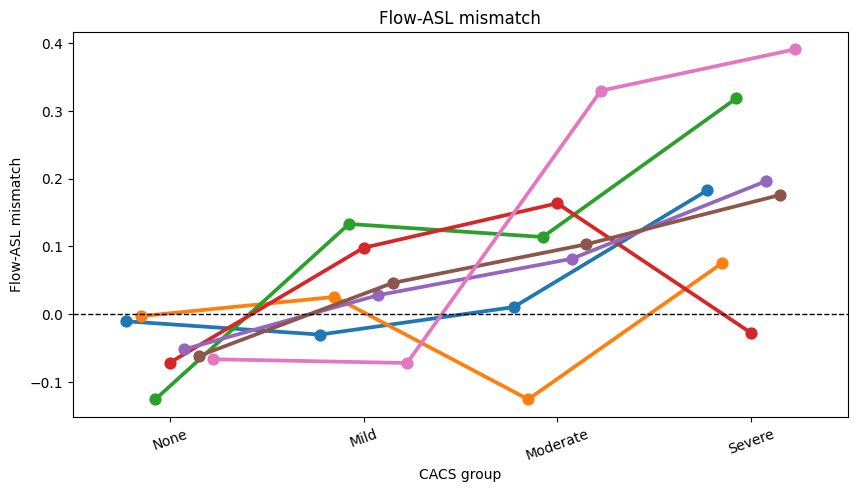

In [82]:
model_df = pair_long[
  [
      "patient_id",
      "micro_cbf_z",
      "macro_flow_z",
      "pair_label",
      "tacsctot_group",
      "age_c",
      "sex",
      "Hematocrit",
      "flow_cbf_mismatch_z"
  ]
].dropna().reset_index(drop=True)

res_mismatch = smf.mixedlm(
    "flow_cbf_mismatch_z ~ C(tacsctot_group, Treatment('None')) * C(pair_label, Treatment('MCA')) + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
lineplot_from_long(ax, model_df, "flow_cbf_mismatch_z", "Flow-ASL mismatch", "Flow-ASL mismatch")
plt.show()

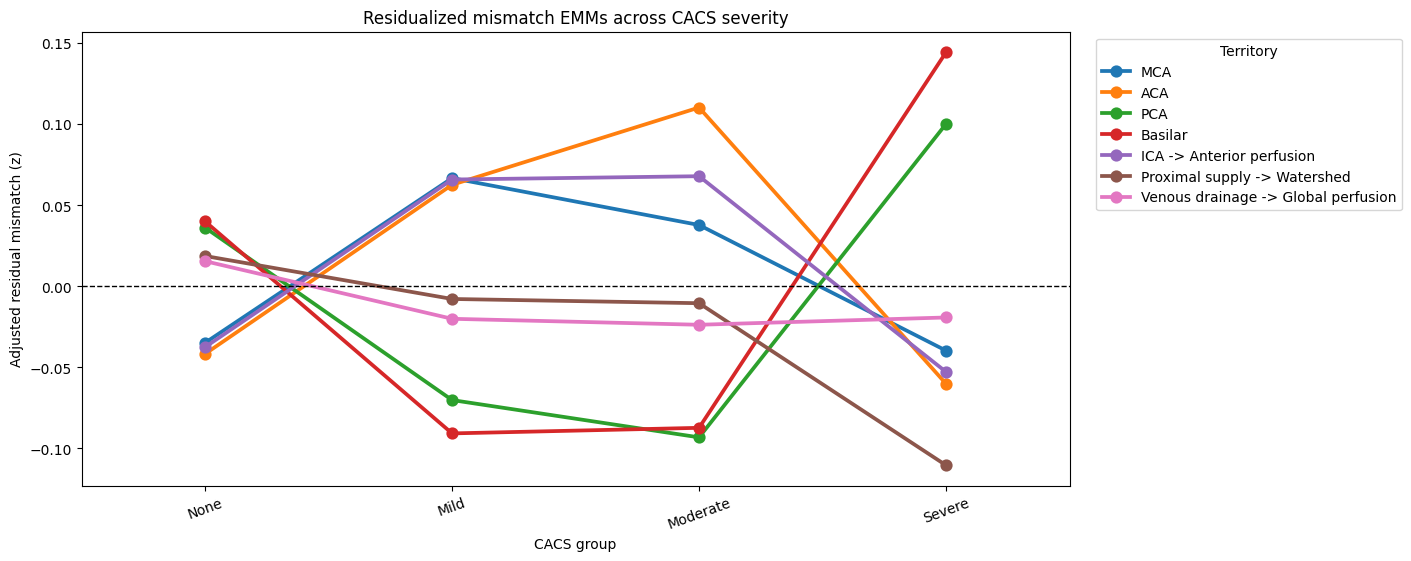

In [91]:
model_df = pair_long[
  [
      "patient_id",
      "micro_cbf_z",
      "macro_flow_z",
      "pair_label",
      "tacsctot_group",
      "SCORE2",
      "age_c",
      "sex",
      "Hematocrit",
  ]
].dropna().reset_index(drop=True)

res_expected = smf.mixedlm(
    "micro_cbf_z ~ macro_flow_z + C(pair_label, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()

model_df['cbf_expected_z'] = res_expected.fittedvalues
model_df['cbf_resid_mismatch_z'] = model_df['micro_cbf_z'] - model_df['cbf_expected_z']

res_resid_mismatch = smf.mixedlm(
    "cbf_resid_mismatch_z ~ C(tacsctot_group, Treatment('None')) * C(pair_label, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()


def _print_resid_mismatch_emm(df, mm_res, territory_order, additional_cols=None):
    def predict_fixed_ci_from_model(res, new_df):
        X = patsy.build_design_matrices(
            [res.model.data.design_info],
            new_df,
            return_type="dataframe",
        )[0]
        fe = res.fe_params
        cov = res.cov_params().loc[fe.index, fe.index]
        X = X.reindex(columns=fe.index, fill_value=0.0)

        pred = X @ fe
        se = np.sqrt(np.sum((X @ cov) * X, axis=1))

        out = new_df.copy()
        out["estimate"] = pred
        out["SE"] = se
        out["lower"] = pred - 1.96 * se
        out["upper"] = pred + 1.96 * se
        return out

    sex_ref = 0          # female
    age_ref = 0          # because age_c is centered
    hematocrit_ref = float(df["Hematocrit"].mean())

    emm_grid = pd.DataFrame(
        [(g, t) for g in cacs_order for t in territory_order],
        columns=["tacsctot_group", "pair_label"],
    )
    emm_grid["tacsctot_group"] = pd.Categorical(
        emm_grid["tacsctot_group"], categories=cacs_order, ordered=True
    )
    emm_grid["pair_label"] = pd.Categorical(
        emm_grid["pair_label"], categories=territory_order, ordered=True
    )
    emm_grid["age_c"] = age_ref
    emm_grid["sex"] = sex_ref
    emm_grid["Hematocrit"] = hematocrit_ref

    if additional_cols:
        for col in additional_cols:
            # use 0 only if the variable is centered; otherwise use the mean
            emm_grid[col] = 0

    emm_df = predict_fixed_ci_from_model(mm_res, emm_grid)


    cacs_score_map = {g: i for i, g in enumerate(cacs_order)}
    emm_df["cacs_score"] = emm_df["tacsctot_group"].map(cacs_score_map).astype(float)

    slope_rows = []
    for terr in territory_order:
        sub = emm_df[emm_df["pair_label"] == terr].sort_values("cacs_score")
        slope = np.polyfit(sub["cacs_score"], sub["estimate"], 1)[0]
        severe_minus_none = float(
            sub.loc[sub["tacsctot_group"] == "Severe", "estimate"].iloc[0]
            - sub.loc[sub["tacsctot_group"] == "None", "estimate"].iloc[0]
        )
        slope_rows.append(
            {
                "pair_label": terr,
                "emm_slope_per_cacs_step": slope,
                "severe_minus_none": severe_minus_none,
            }
        )

    emm_slope_df = pd.DataFrame(slope_rows).sort_values("emm_slope_per_cacs_step")
    # print("\nEMM-based slopes for residualized mismatch by territory:")
    # print(emm_slope_df)

    fig, axes = plt.subplots(1, 1, figsize=(14, 5.5), constrained_layout=True)

    sns.pointplot(
        data=emm_df,
        x="cacs_score",
        y="estimate",
        hue="pair_label",
        # palette=base_territory_palette,
        errorbar=None,
        markers="o",
        linestyles="-",
        ax=axes,
    )
    axes.axhline(0, ls="--", c="black", lw=1)
    axes.set_xticks(range(len(cacs_order)))
    axes.set_xticklabels(cacs_order, rotation=20)
    axes.set_title("Residualized mismatch EMMs across CACS severity")
    axes.set_xlabel("CACS group")
    axes.set_ylabel("Adjusted residual mismatch (z)")

    handles, labels = axes.get_legend_handles_labels()
    if handles:
        axes.legend(handles, labels, title="Territory", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.show()

    return emm_df, emm_slope_df

emm_df, emm_slope_df = _print_resid_mismatch_emm(model_df, res_resid_mismatch, combined_pair_order, additional_cols=["SCORE2"])

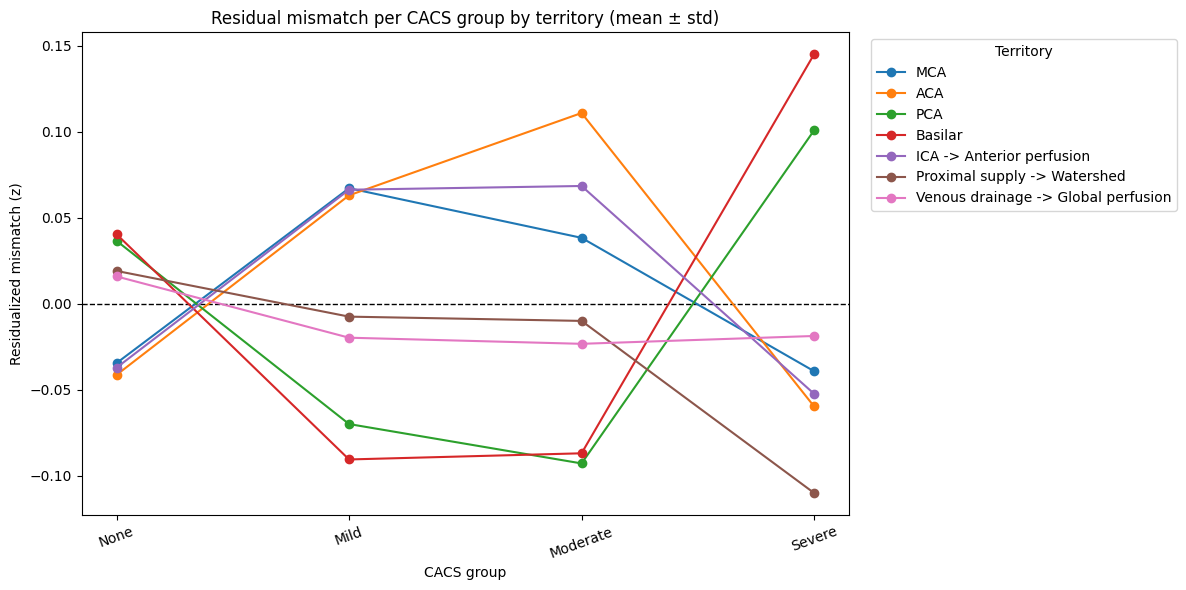

In [24]:
model_df = pair_long[
  [
      "patient_id",
      "micro_cbf_z",
      "macro_flow_z",
      "pair_label",
      "tacsctot_group",
      "SCORE2",
      "age_c",
      "sex",
      "Hematocrit",
  ]
].dropna().reset_index(drop=True)

res_expected = smf.mixedlm(
    "micro_cbf_z ~ macro_flow_z + C(pair_label, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()

model_df['cbf_expected_z'] = res_expected.fittedvalues
model_df['cbf_resid_mismatch_z'] = model_df['micro_cbf_z'] - model_df['cbf_expected_z']

import matplotlib.pyplot as plt

# Compute group means and std of the residual mismatch z by CACS group and territory
plot_df = model_df.groupby(["tacsctot_group", "pair_label"])["cbf_resid_mismatch_z"].agg(["mean", "std"]).reset_index()

# Prepare plotting order
territory_order = plot_df["pair_label"].unique()
cacs_order = ["None", "Mild", "Moderate", "Severe"]
plot_df["tacsctot_group"] = pd.Categorical(plot_df["tacsctot_group"], categories=cacs_order, ordered=True)
plot_df = plot_df.sort_values(["pair_label", "tacsctot_group"])

fig, ax = plt.subplots(figsize=(12,6))

for i, territory in enumerate(territory_order):
    subdf = plot_df[plot_df["pair_label"] == territory]
    means = subdf["mean"]
    stds = subdf["std"]
    ax.errorbar(
        x=np.arange(len(cacs_order)), 
        y=means, 
        # yerr=stds,
        label=territory,
        marker="o",
        capsize=5,
        linestyle="-"
    )

ax.axhline(0, ls="--", c="black", lw=1)
ax.set_xticks(np.arange(len(cacs_order)))
ax.set_xticklabels(cacs_order, rotation=20)
ax.set_xlabel("CACS group")
ax.set_ylabel("Residualized mismatch (z)")
ax.set_title("Residual mismatch per CACS group by territory (mean ± std)")
ax.legend(title="Territory", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

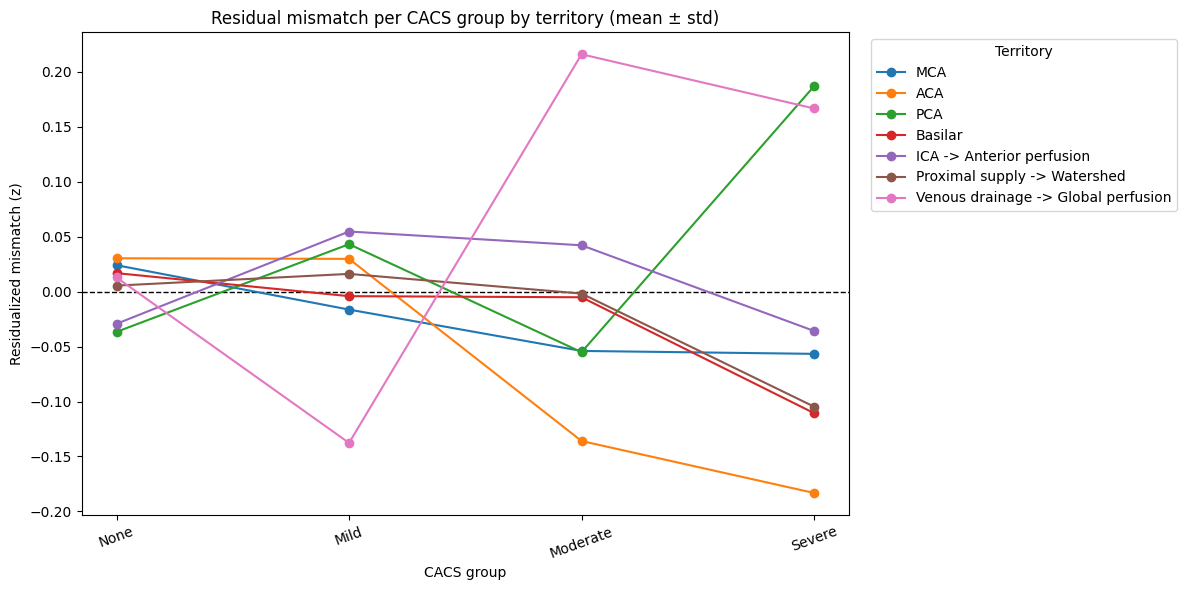

In [25]:
model_df = pair_long[
  [
      "patient_id",
      "micro_cbf_z",
      "macro_flow_z",
      "pair_label",
      "tacsctot_group",
      "SCORE2",
      "age_c",
      "sex",
      "Hematocrit",
  ]
].dropna().reset_index(drop=True)

res_expected = smf.mixedlm(
    "macro_flow_z ~ micro_cbf_z + C(pair_label, Treatment('MCA')) + SCORE2 + age_c + sex + Hematocrit",
    data=model_df,
    groups=model_df["patient_id"],
    re_formula="1",
).fit()

model_df['cbf_expected_z'] = res_expected.fittedvalues
model_df['cbf_resid_mismatch_z'] = model_df['macro_flow_z'] - model_df['cbf_expected_z']

import matplotlib.pyplot as plt

# Compute group means and std of the residual mismatch z by CACS group and territory
plot_df = model_df.groupby(["tacsctot_group", "pair_label"])["cbf_resid_mismatch_z"].agg(["mean", "std"]).reset_index()

# Prepare plotting order
territory_order = plot_df["pair_label"].unique()
cacs_order = ["None", "Mild", "Moderate", "Severe"]
plot_df["tacsctot_group"] = pd.Categorical(plot_df["tacsctot_group"], categories=cacs_order, ordered=True)
plot_df = plot_df.sort_values(["pair_label", "tacsctot_group"])

fig, ax = plt.subplots(figsize=(12,6))

for i, territory in enumerate(territory_order):
    subdf = plot_df[plot_df["pair_label"] == territory]
    means = subdf["mean"]
    stds = subdf["std"]
    ax.errorbar(
        x=np.arange(len(cacs_order)), 
        y=means, 
        # yerr=stds,
        label=territory,
        marker="o",
        capsize=5,
        linestyle="-"
    )

ax.axhline(0, ls="--", c="black", lw=1)
ax.set_xticks(np.arange(len(cacs_order)))
ax.set_xticklabels(cacs_order, rotation=20)
ax.set_xlabel("CACS group")
ax.set_ylabel("Residualized mismatch (z)")
ax.set_title("Residual mismatch per CACS group by territory (mean ± std)")
ax.legend(title="Territory", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [92]:
emm_df

,tacsctot_group,pair_label,age_c,sex,Hematocrit,SCORE2,estimate,SE,lower,upper,cacs_score
0,None,MCA,0,0,45.021559,0,-0.034806,0.027044,-0.087811,0.018200,0.0
1,None,ACA,0,0,45.021559,0,-0.041656,0.027044,-0.094662,0.011349,0.0
2,None,PCA,0,0,45.021559,0,0.036232,0.027044,-0.016774,0.089237,0.0
3,None,Basilar,0,0,45.021559,0,0.040058,0.027242,-0.013335,0.093452,0.0
4,None,ICA -> Anterior perfusion,0,0,45.021559,0,-0.037476,0.027242,-0.090869,0.015918,0.0
5,None,Proximal supply -> Watershed,0,0,45.021559,0,0.018737,0.027242,-0.034657,0.072131,0.0
6,None,Venous drainage -> Global perfusion,0,0,45.021559,0,0.015549,0.027044,-0.037456,0.068555,0.0
7,Mild,MCA,0,0,45.021559,0,0.066816,0.035492,-0.002749,0.136381,1.0
8,Mild,ACA,0,0,45.021559,0,0.062688,0.035492,-0.006877,0.132253,1.0
9,Mild,PCA,0,0,45.021559,0,-0.070166,0.035492,-0.139731,-0.000601,1.0


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
# import yabplot as yab

# -------------------------------------------------------------------
# Actual atlas path + IDs already aligned with your vascular atlas
# -------------------------------------------------------------------
atlas_path = db_base_path / "ATLAS" / "ctx_arterial_atlas_watershed_filled.nii.gz"

atlas_id_to_label = {
    1: "L ACA",
    2: "R ACA",
    3: "L MCA",
    4: "R MCA",
    5: "L PCA",
    6: "R PCA",
    7: "L Basilar",
    8: "R Basilar",
    11: "Watershed",
}

pair_to_atlas_labels = {
    "MCA": ["L MCA", "R MCA"],
    "ACA": ["L ACA", "R ACA"],
    "PCA": ["L PCA", "R PCA"],
    "Basilar": ["L Basilar", "R Basilar"],
    "ICA -> Anterior perfusion": ["L ACA", "R ACA", "L MCA", "R MCA"],
    "Proximal supply -> Watershed": ["Watershed"],
    "Venous drainage -> Global perfusion": [
        "L ACA", "R ACA", "L MCA", "R MCA",
        "L PCA", "R PCA", "L Basilar", "R Basilar",
        "Watershed",
    ],
}

